# Clasificación de Residuos — Modelo A3: CNN Medium

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de complejidad creciente** para estudiar el impacto de la arquitectura en el rendimiento de redes neuronales convolucionales aplicadas a la clasificación de residuos.

### Estrategia Experimental

- **Punto de partida**: Modelo baseline A1 (red simple del notebook 2.3)
- **Enfoque**: Incrementos progresivos en la capacidad del modelo
- **Observables**: Evolución del error de entrenamiento y validación

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo A3

### Descripción

**CNN Medium** representa un salto significativo en complejidad respecto a A2. Introduce **MaxPooling** para reducción espacial y añade una **segunda capa convolucional** con más filtros, permitiendo aprender características jerárquicas.

### Modificaciones Respecto a A2

| Componente | A2 (Anterior) | A3 (Este modelo) |
|------------|---------------|------------------|
| **Capas Conv** | 1 capa (32 filtros) | **2 capas** (32 → 64 filtros) |
| **MaxPooling** | No | **Sí** (después de conv1) |
| **Reducción espacial** | Solo GAP | MaxPool + GAP |
| **Parámetros** | ~1K | **~20K** |

**Hipótesis**: El pooling permite reducir la dimensionalidad espacial y la segunda capa debería capturar características de mayor nivel (bordes → texturas).

---
### **Resumen rendimiento en el conjunto de Test**

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.61 | 0.66 | 0.56 | 0.57 |
| **A3 (CNN Medium)** | **19,782** | **0.7263** | **0.7114** | **0.6884** | **0.6973** |
---

## Implementación

A continuación se entrena y evalúa el modelo A3 usando el pipeline estándar del proyecto.

In [1]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score  
)


# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

2026-03-13 10:40:14.126582: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 10:40:14.126788: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 10:40:14.153555: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 10:40:14.957023: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

---
## 1. Carga de datos

In [2]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


---
## 2. Definición del modelo

In [3]:
# ========================================
# 3. DEFINICION DEL MODELO A3
# ========================================

from models.A3_cnn_medium import build_cnn_medium as build_model

model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1773394823.655089 2165763 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773394823.661262 2165763 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "A3_CNN_Medium"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,782 (77.27 KB)

 Trainable params: 19,782 (77.27 KB)

 Non-trainable params: 0 (0.00 B)

---
## 3. Entrenamiento

In [ ]:
# ========================================
# 4. CONFIGURACION Y ENTRENAMIENTO
# ========================================

MODEL_NAME = 'A3_cnn_medium'

# ── Learning Rate Scheduler ──────────────────────────────────────────────────
# Estrategia: Cosine Annealing | comienza alto (0.01) y decae suavemente
num_train_samples = len(X_train)
batch_size = 64 
steps_per_epoch = num_train_samples // batch_size
total_steps = steps_per_epoch * 200  # 200 épocas

lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,  
    decay_steps=total_steps,
    alpha=1e-4  
)

# ── Callbacks ───────────────────────────────────────────────────────────────
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_loss', save_best_only=True, verbose=0)

# ── Compilar ─────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_scheduler),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Entrenamiento ────────────────────────────────────────────────────────────
history_p1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[cb_checkpoint],
    verbose=1
)

Epoch 1/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.2443 - loss: 1.7220 - val_accuracy: 0.2348 - val_loss: 1.6999
Epoch 2/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.2834 - loss: 1.6680 - val_accuracy: 0.3879 - val_loss: 1.6227
Epoch 3/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.3614 - loss: 1.5936 - val_accuracy: 0.3958 - val_loss: 1.5611
Epoch 4/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.3869 - loss: 1.5380 - val_accuracy: 0.3879 - val_loss: 1.5156
Epoch 5/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4061 - loss: 1.4998 - val_accuracy: 0.4063 - val_loss: 1.4851
Epoch 6/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4072 - loss: 1.4731 - val_accuracy: 0.3879 - val_loss: 1.4600
Epoch 7/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4191 - loss: 1.4529 - val_accuracy: 0.4248 - val_loss: 1.4354
Epoch 8/200
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.4259 - loss: 1.4358 - val_accu

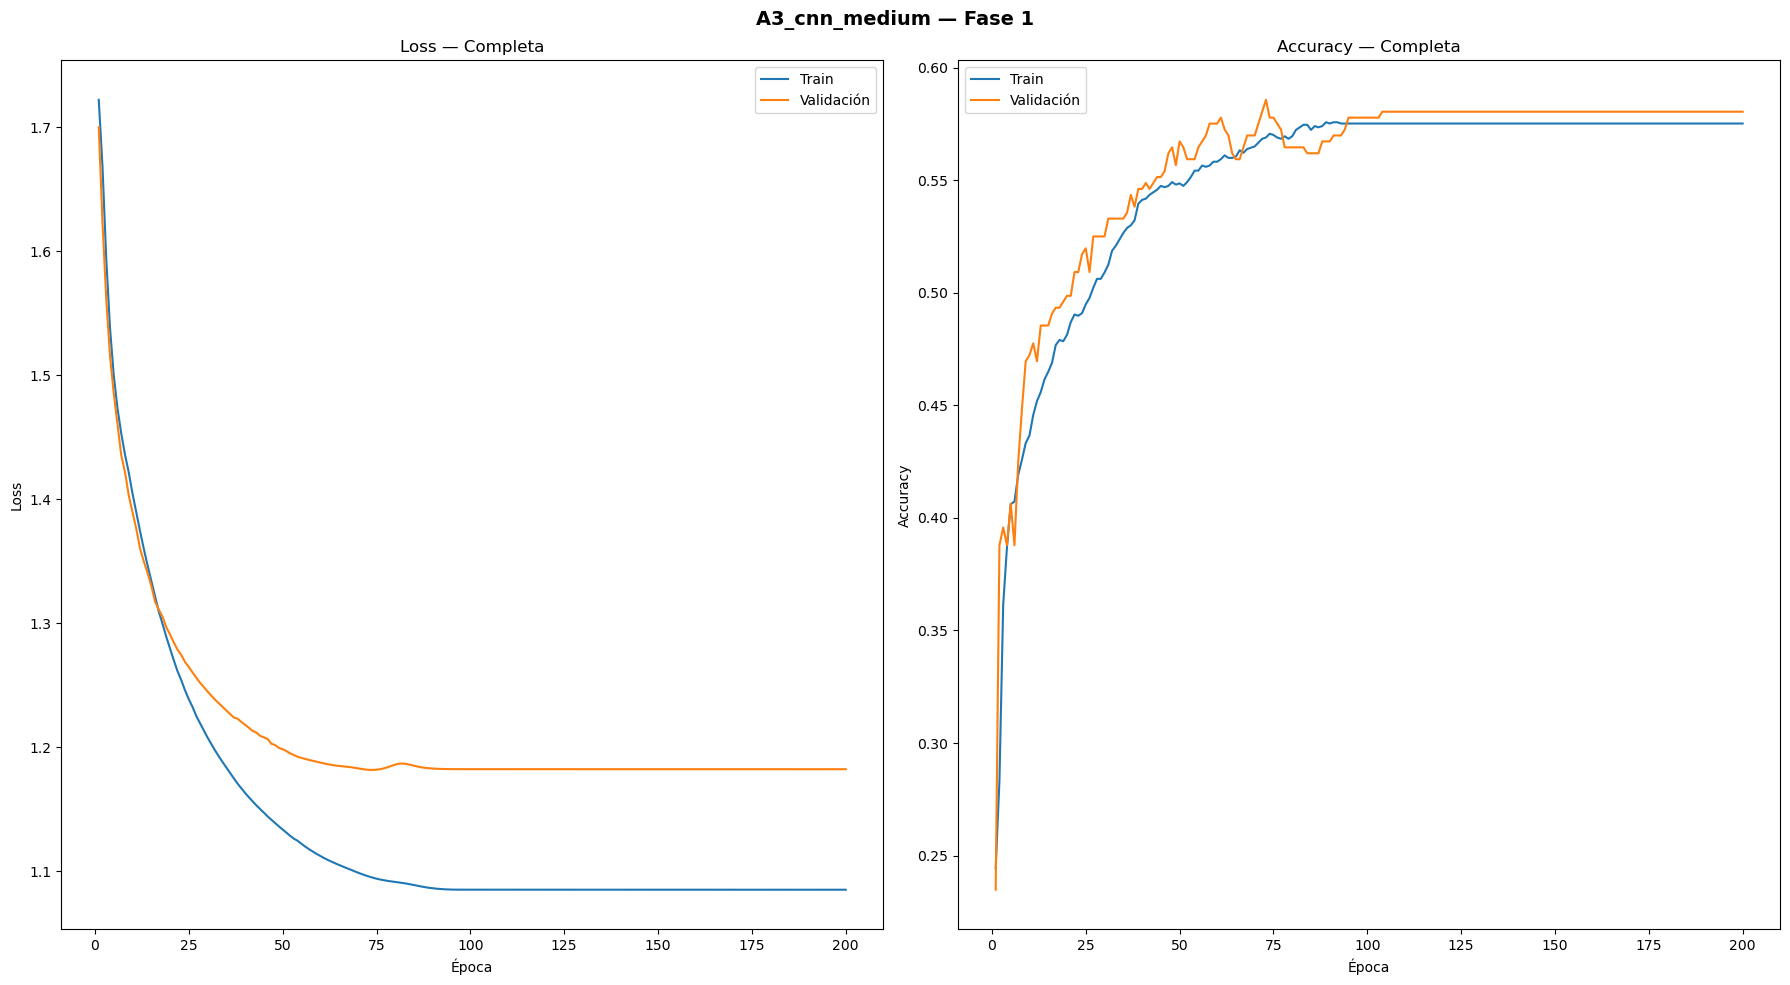

### Entrenamiento alternativo (DEFINITIVO)

In [6]:
# ========================================
# 4B. ENTRENAMIENTO ALTERNATIVO (SIN COSINE, ESTILO A2)
# ========================================
# No reemplaza el entrenamiento actual; solo añade una variante opcional.

USE_PLATEAU_TRAINING = True  # Cambiar a True para ejecutar esta variante
MODEL_NAME_PLATEAU = 'A3_cnn_medium_plateau'

if USE_PLATEAU_TRAINING:
    model_plateau = build_model(input_shape=(224, 224, 3), num_classes=6)

    cb_reduce_lr_plateau = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    )

    cb_checkpoint_plateau = callbacks.ModelCheckpoint(
        filepath=f'best_{MODEL_NAME_PLATEAU}_phase1.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    model_plateau.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=3e-3,
            weight_decay=1e-4
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_p1_plateau = model_plateau.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=250,
        callbacks=[cb_reduce_lr_plateau, cb_checkpoint_plateau],
        verbose=1
    )

# Si quieres usar este modelo en evaluación, descomenta estas líneas:
model = model_plateau
history_p1 = history_p1_plateau
MODEL_NAME = MODEL_NAME_PLATEAU

Epoch 1/250
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.2152 - loss: 1.7401
Epoch 1: val_accuracy improved from None to 0.37203, saving model to best_A3_cnn_medium_plateau_phase1.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.2234 - loss: 1.7248 - val_accuracy: 0.3720 - val_loss: 1.6745 - learning_rate: 0.0030
Epoch 2/250
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3333 - loss: 1.6257
Epoch 2: val_accuracy did not improve from 0.37203
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.3558 - loss: 1.5987 - val_accuracy: 0.3641 - val_loss: 1.5650 - learning_rate: 0.0030
Epoch 3/250
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3286 - loss: 1.5676
Epoch 3: val_accuracy did not improve from 0.37203
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.3360 - loss: 1.5676 - val_accuracy: 0.3325 - val_loss: 1.5578 - learning_rate: 0.0030
Epoch 4/250
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3734 - loss: 1.5286
Epoch 4: val_accur

---
## 4. Curvas de entrenamiento

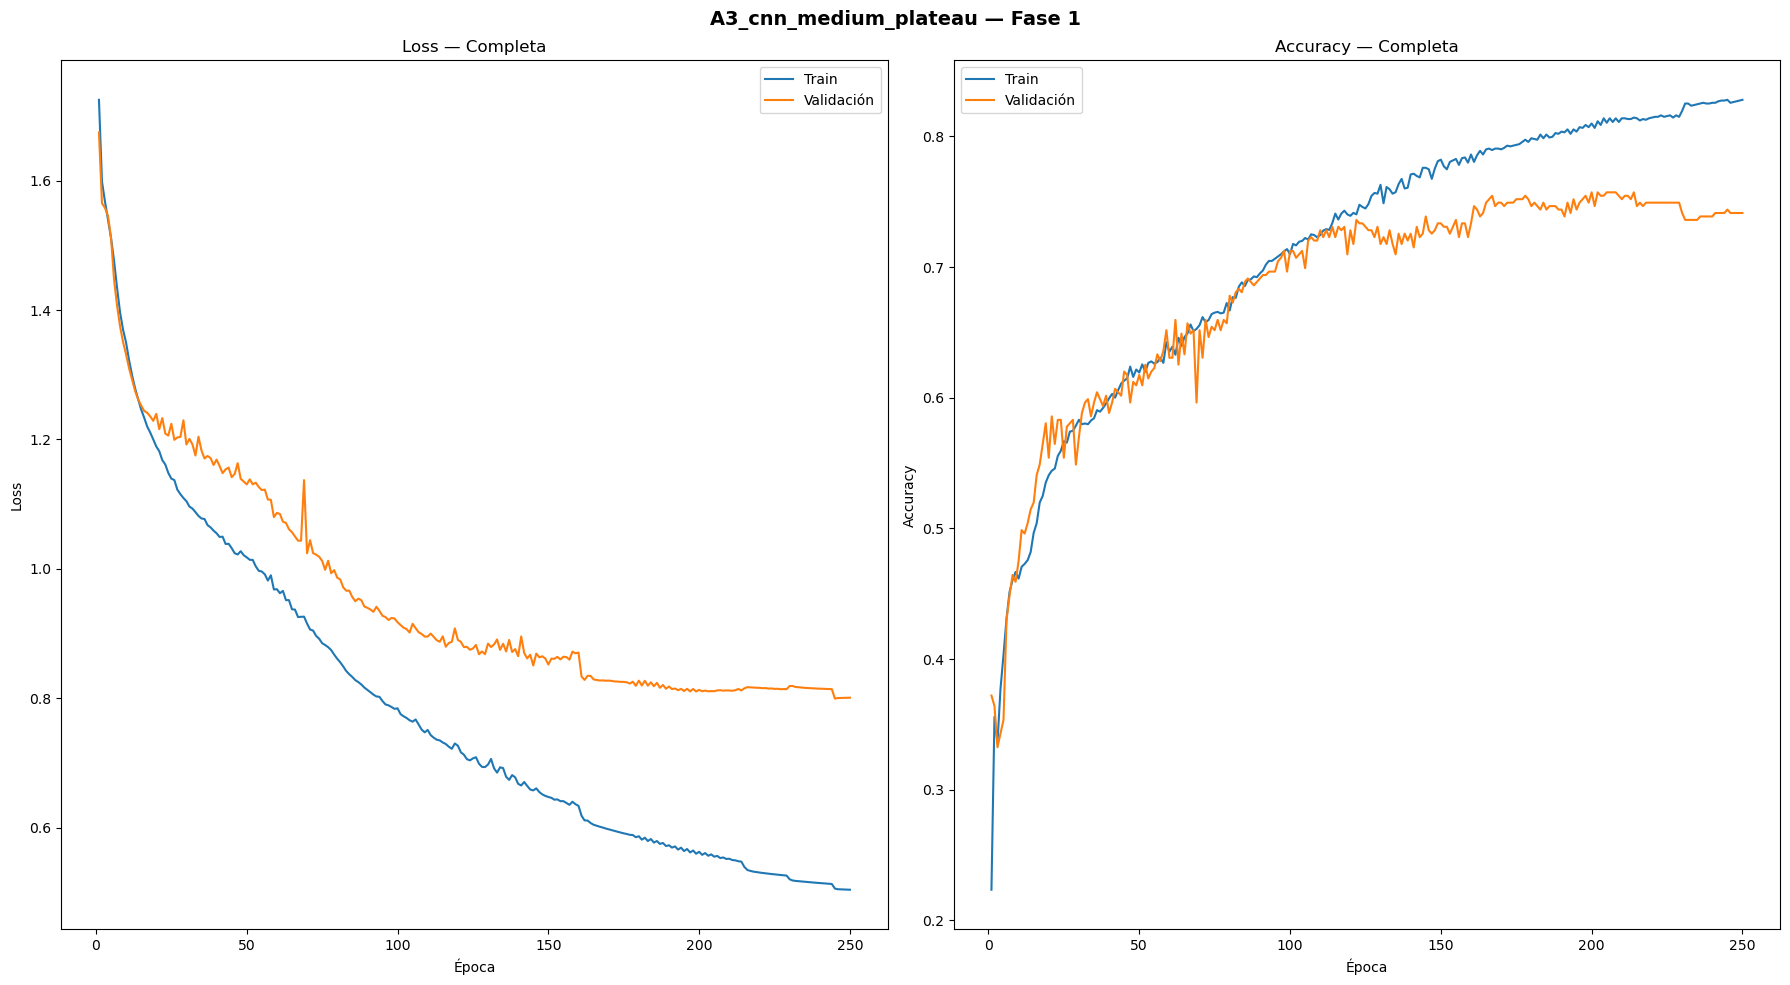

In [9]:
def smooth(values, weight=0.85):
    """Suavizado exponencial (similar a TensorBoard)."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + (1 - weight) * v
        smoothed.append(last)
    return smoothed


def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Fila 1: Loss ─────────────────────────────────────────────────────────
    # 1a) Curva completa
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Fila 2: Accuracy ─────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()


plot_training(history_p1, title=MODEL_NAME, phase=1)

---
## 5. Evaluación — Train / Val / Test

In [10]:
def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


print('=' * 60)
print(f'Modelo: {MODEL_NAME}')
print('=' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('=' * 60)

Modelo: A3_cnn_medium_plateau
[Train]  Acc=0.8360  Prec=0.8268  Rec=0.8121  F1=0.8184
[  Val]  Acc=0.7414  Prec=0.7149  Rec=0.6954  F1=0.7010
[ Test]  Acc=0.7263  Prec=0.7114  Rec=0.6884  F1=0.6973


In [11]:
# ── Número de parámetros (para la tabla del README) ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 19,782
Parámetros entrenables: 19,782


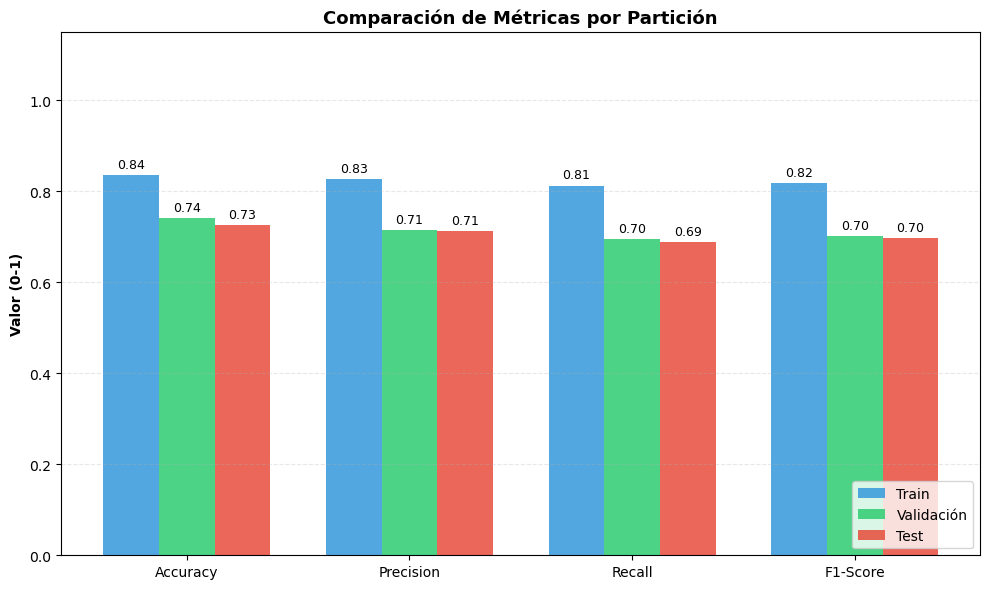

In [12]:
# ========================================
# GRAFICO DE BARRAS DE METRICAS (TRAIN / VAL / TEST)
# ========================================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

results_train = [res_train['acc'], res_train['prec'], res_train['rec'], res_train['f1']]
results_val   = [res_val['acc'],   res_val['prec'],   res_val['rec'],   res_val['f1']]
results_test  = [res_test['acc'],  res_test['prec'],  res_test['rec'],  res_test['f1']]

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, results_train, width, label='Train', color='#3498db', alpha=0.85)
rects2 = ax.bar(x,         results_val,   width, label='Validación', color='#2ecc71', alpha=0.85)
rects3 = ax.bar(x + width, results_test,  width, label='Test', color='#e74c3c', alpha=0.85)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9
        )

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparación de Métricas por Partición', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 6. Matriz de confusión

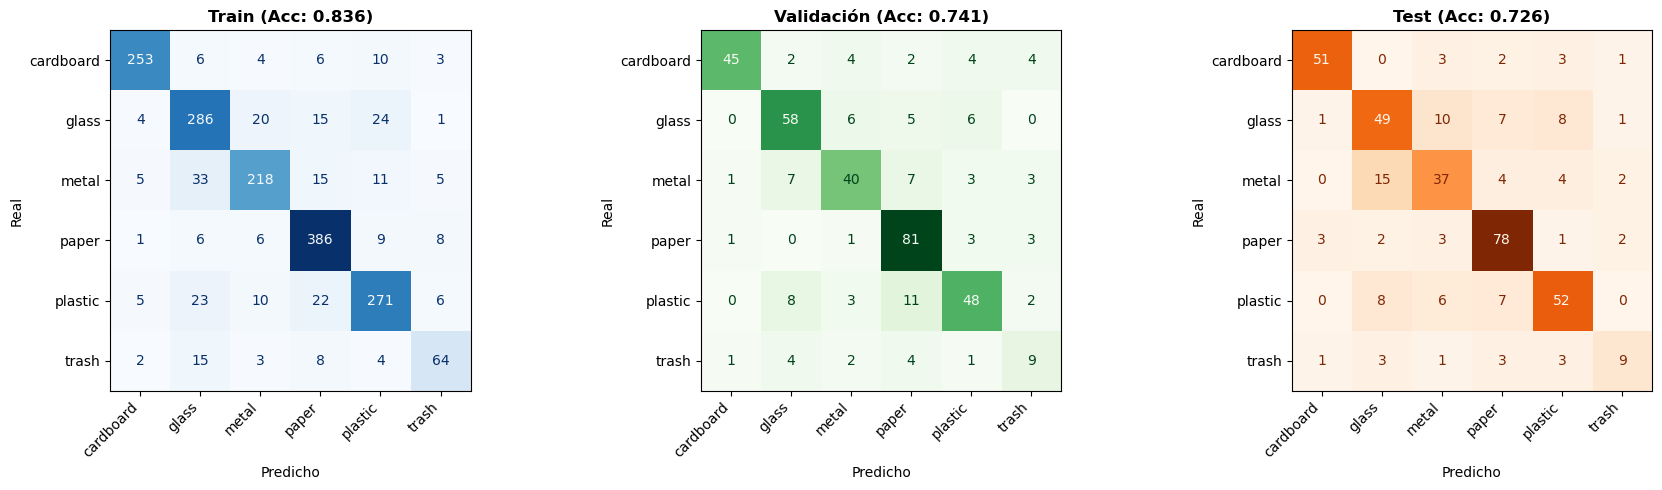

In [13]:
# ========================================
# MATRICES DE CONFUSION PARA TRAIN / VAL / TEST
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_pred_train = res_train['y_pred']
y_pred_val   = res_val['y_pred']
y_pred_test  = res_test['y_pred']

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Train (Acc: {results_train[0]:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicho', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validación
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Validación (Acc: {results_val[0]:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicho', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title(f"Test (Acc: {results_test[0]:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicho', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 7. Conclusiones — Modelo A3 (CNN Medium)

El modelo **A3_CNN_Medium** introduce dos cambios estructurales clave respecto a A2: una segunda capa convolucional (32 → 64 filtros) y `MaxPooling` para reducción espacial explícita.

En este experimento se observa que:

- La variante **ReduceLROnPlateau** (`A3_cnn_medium_plateau`) fue más estable que CosineDecay, logrando mejor accuracy en validación.
- La validación se **estancó** alrededor de la época ~150 (val_loss ≈ 0.80, val_acc ≈ 0.74), mientras que el loss de entrenamiento siguió bajando — señal de sobreajuste incipiente.
- **Entrenar más épocas no mejorará el rendimiento**: la brecha train/val indica que el modelo ha agotado su capacidad de generalización con esta arquitectura. El checkpoint guardado con `monitor='val_accuracy'` en `best_A3_cnn_medium_plateau_phase1.keras` es el mejor modelo.
- El salto de A2 → A3 es significativo, confirmando que el MaxPooling y la segunda capa convolucional permiten capturar más características.

### Comparación de modelos: A1 vs A2 vs A3
| Modelo | Partición | Accuracy | Precision | Recall | F1-Score |
|--------|-----------|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | Train | 0.4717 | 0.4138 | 0.4100 | 0.3937 |
| A1 (SimpleCNN) | Val | 0.4802 | 0.4406 | 0.4138 | 0.4030 |
| A1 (SimpleCNN) | Test | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | Train | 0.64 | 0.63 | 0.57 | 0.57 |
| A2 (CNN Small) | Val | 0.62 | 0.65 | 0.55 | 0.56 |
| A2 (CNN Small) | Test | 0.61 | 0.66 | 0.56 | 0.57 |
| **A3 (CNN Medium)** | **Train** | **0.8360** | **0.8268** | **0.8121** | **0.8184** |
| **A3 (CNN Medium)** | **Val** | **0.7414** | **0.7149** | **0.6954** | **0.7010** |
| **A3 (CNN Medium)** | **Test** | **0.7263** | **0.7114** | **0.6884** | **0.6973** |


### Comparación de rendimiento en el conjunto de Test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.61 | 0.66 | 0.56 | 0.57 |
| **A3 (CNN Medium)** | **19,782** | **0.7263** | **0.7114** | **0.6884** | **0.6973** |
